In [22]:
!pip install yfinance

In [23]:
import yfinance as yf
import pandas as pd

# Define stocks to download (NSE India)
tickers = ["RELIANCE.NS", "TCS.NS", "INFY.NS"]

# Download 5 years of daily historical data
for ticker in tickers:
    df = yf.download(
        ticker,
        start="2019-01-01",
        end="2024-01-01",
        auto_adjust=True
    )
    df.to_csv(f"data/{ticker.replace('.NS','')}_raw.csv")
    print(f"Downloaded {len(df)} rows for {ticker}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Downloaded 1235 rows for RELIANCE.NS
Downloaded 1235 rows for TCS.NS



[*********************100%***********************]  1 of 1 completed

Downloaded 1235 rows for INFY.NS


In [24]:
df = pd.read_csv("data/RELIANCE_raw.csv")
print(df.shape)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())

(1237, 6)
        Price               Close                High                 Low  \
0      Ticker         RELIANCE.NS         RELIANCE.NS         RELIANCE.NS   
1        Date                 NaN                 NaN                 NaN   
2  2019-01-01   498.4905700683594  501.29211717323517  493.64353558398005   
3  2019-01-02  491.99822998046875  501.15872336812794   489.5969165762727   
4  2019-01-03   485.9283447265625  495.64467817229274   484.7499362934948   

                 Open       Volume  
0         RELIANCE.NS  RELIANCE.NS  
1                 NaN          NaN  
2    500.380511591524      9746670  
3  495.60015556027656     15628818  
4  492.48742341513827     16288287  
Price     object
Close     object
High      object
Low       object
Open      object
Volume    object
dtype: object
Price     0
Close     1
High      1
Low       1
Open      1
Volume    1
dtype: int64


In [25]:
#BASIC DATA

In [26]:
import pandas as pd

df = pd.read_csv("data/RELIANCE_raw.csv", index_col="Price", parse_dates=True)

C:\Users\satyanarayan kumawat\AppData\Local\Temp\ipykernel_9772\211937349.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("data/RELIANCE_raw.csv", index_col="Price", parse_dates=True)


In [27]:
# Shape and column names

print(df.shape)
print(df.columns.tolist())

(1237, 5)
['Close', 'High', 'Low', 'Open', 'Volume']


In [28]:
# Summary statistics — mean, min, max, std

print(df.describe())

                     Close         High          Low         Open       Volume
count                 1236         1236         1236         1236         1236
unique                1220         1236         1236         1236         1236
top     1179.8155517578125  RELIANCE.NS  RELIANCE.NS  RELIANCE.NS  RELIANCE.NS
freq                     2            1            1            1            1


In [29]:
# checking for missing value
print(df.isnull().sum())

Close     1
High      1
Low       1
Open      1
Volume    1
dtype: int64


In [30]:
# convert valid number to numeric
df["Close"] = pd.to_numeric(df["Close"], errors="coerce")

In [31]:
# Daily % change in closing price

df["daily_return"] = df["Close"].pct_change() * 100
print(df[["Close", "daily_return"]].tail(10))

                  Close  daily_return
Price                                
2023-12-15  1238.632446      1.276315
2023-12-18  1251.239014      1.017781
2023-12-19  1269.652710      1.471637
2023-12-20  1254.291382     -1.209884
2023-12-21  1271.861450      1.400796
2023-12-22  1273.102173      0.097552
2023-12-26  1279.554443      0.506815
2023-12-27  1283.922119      0.341343
2023-12-28  1293.203369      0.722883
2023-12-29  1282.979126     -0.790614


In [32]:
#CLOSE PRICE PLOT

In [33]:
import matplotlib.pyplot as plt

In [34]:
df.index = pd.to_datetime(df.index, errors="coerce")
df = df.dropna(subset=["Close"])

C:\Users\satyanarayan kumawat\AppData\Local\Temp\ipykernel_9772\2902271898.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index, errors="coerce")


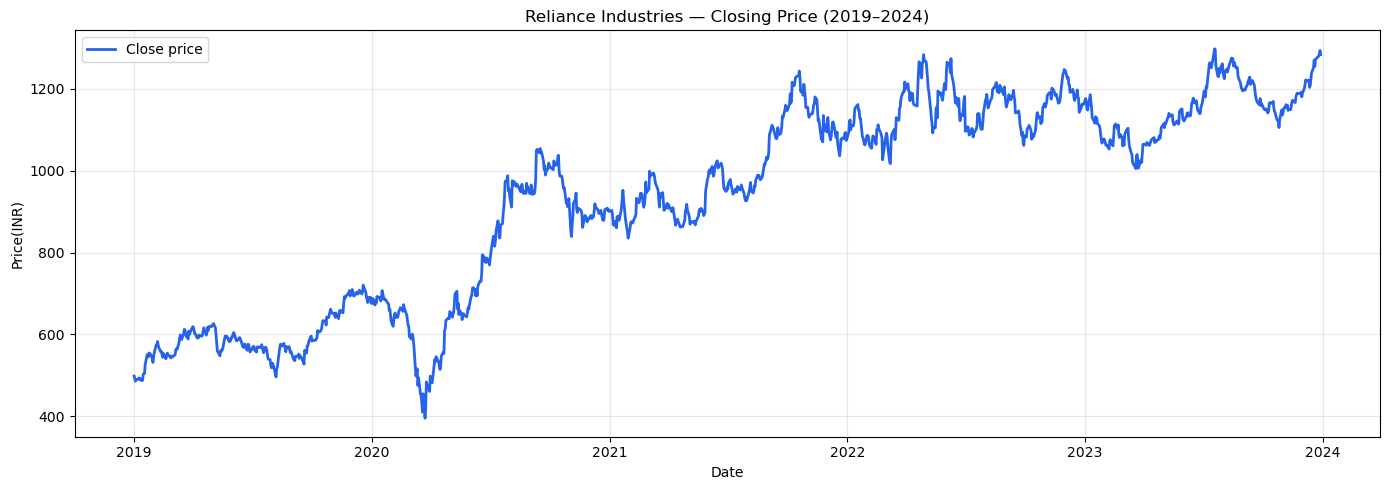

In [35]:
#plotting close price

fig, ax = plt.subplots(figsize=(14,5))

ax.plot(df.index, df["Close"], color="#2563eb", linewidth=2, label="Close price")

ax.set_title("Reliance Industries — Closing Price (2019–2024)")
ax.set_xlabel("Date")
ax.set_ylabel("Price(INR)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("charts/reliance_close.png", dpi=150)
plt.show()

In [36]:
#MOVING AVG PLOTTING

In [37]:
# Calculate 20-day and 50-day moving averages

df["MA20"] = df["Close"].rolling(window=20).mean()
df["MA50"] = df["Close"].rolling(window=50).mean()

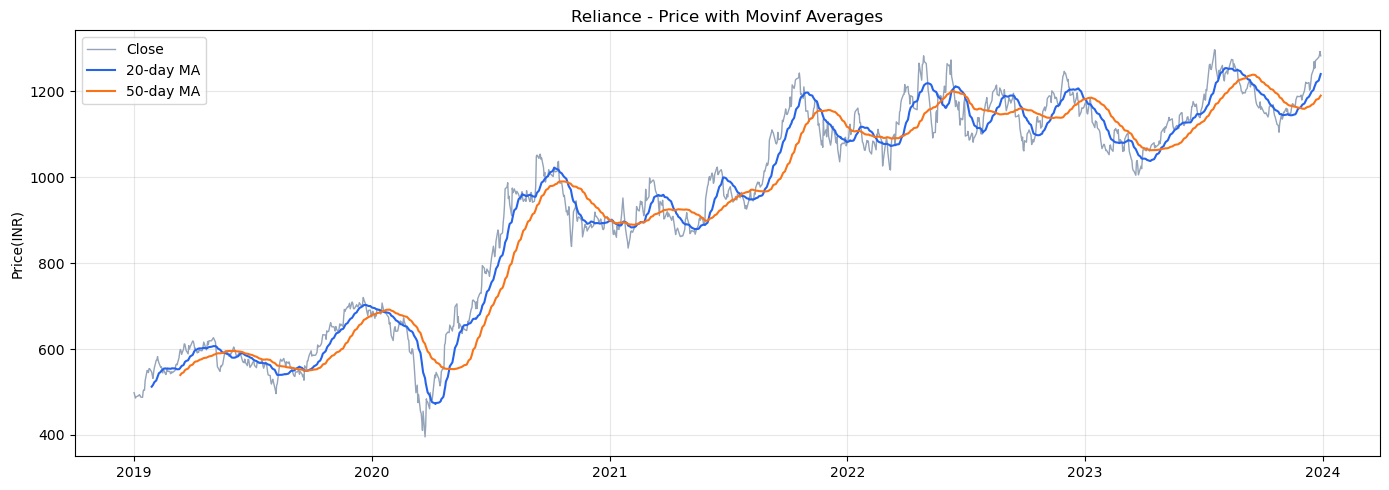

In [38]:
#Plotting moving avg of 20 & 50 days

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df["Close"], color="#94a3b8", linewidth=1 ,label="Close")
ax.plot(df["MA20"], color="#2563eb", linewidth=1.5, label="20-day MA")
ax.plot(df["MA50"], color="#f97316", linewidth=1.5 , label="50-day MA")

ax.set_title("Reliance - Price with Movinf Averages")
ax.set_ylabel("Price(INR)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [39]:
#VOLUME_CHART (Volume bar chart + price together)

In [40]:
df_resampled = df.resample("W").agg({
    "Close": "last",
    "Volume": "sum"
})

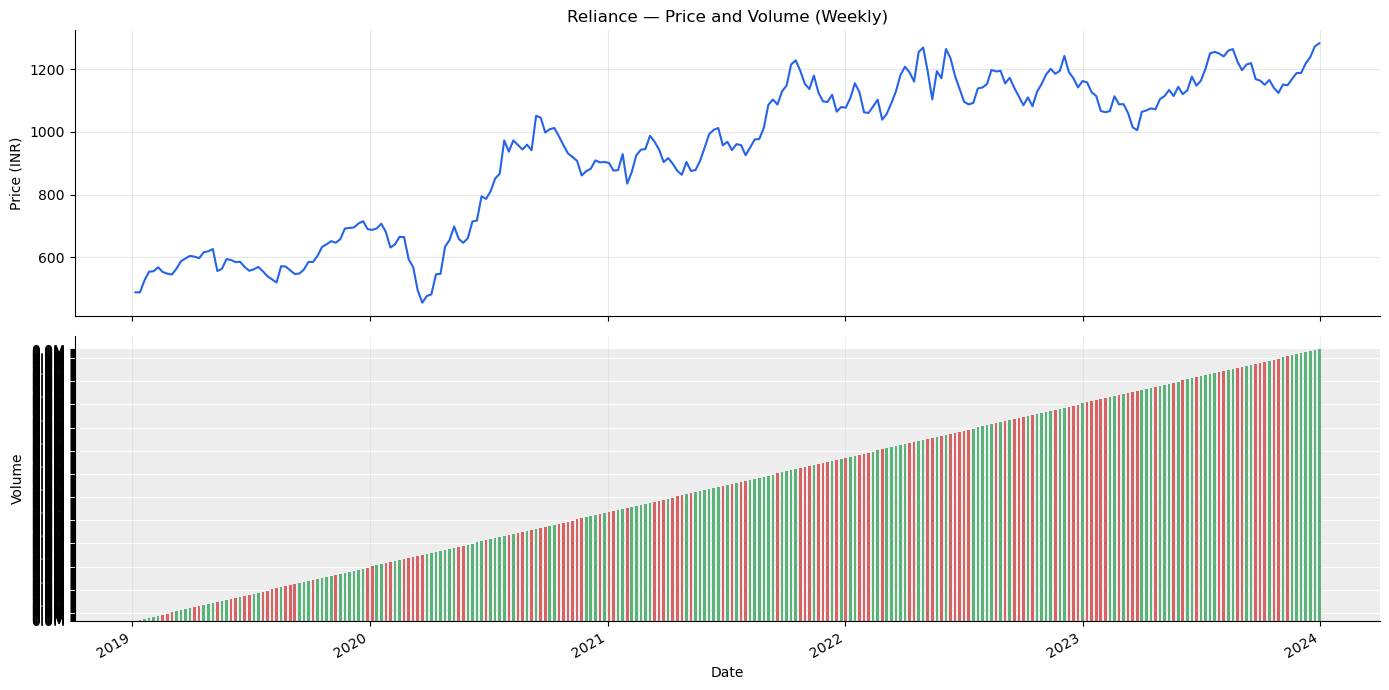

In [41]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# --- Price ---
ax1.plot(df_resampled.index, df_resampled["Close"], color="#2563eb", linewidth=1.5)
ax1.set_ylabel("Price (INR)")
ax1.set_title("Reliance — Price and Volume (Weekly)")
ax1.grid(True, alpha=0.3)

# --- Volume Colors ---
price_diff = df_resampled["Close"].diff()
colors = ["#16a34a" if d >= 0 else "#dc2626" for d in price_diff]

# --- Volume ---
ax2.bar(df_resampled.index, df_resampled["Volume"], color=colors, width=4, alpha=0.8)

ax2.set_ylabel("Volume")
ax2.set_xlabel("Date")
ax2.grid(True, alpha=0.2)

# Format volume (millions)
ax2.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
)

# Clean look
for ax in (ax1, ax2):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [1]:
# import sqlite3
# import pandas as pd

# # ── Load & clean raw data ──────────────────────────────────────
# df = pd.read_csv("data/RELIANCE_raw.csv", index_col=0, parse_dates=True)

# # Flatten multi-level columns (yfinance quirk)
# df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]
# df.index.name = "Date"

# # Remove any stray header rows yfinance sometimes adds
# df = df[~df.index.astype(str).str.contains("Price|Ticker|Date", na=False)]

# # Force numeric types
# for col in ["Open", "High", "Low", "Close", "Volume"]:
#     df[col] = pd.to_numeric(df[col], errors="coerce")

# df.dropna(subset=["Close"], inplace=True)

# print(f"Loaded {len(df)} rows — dtypes OK: {df['Close'].dtype}")

# # ── Trend features ─────────────────────────────────────────────
# df["MA7"]           = df["Close"].rolling(7).mean()
# df["MA20"]          = df["Close"].rolling(20).mean()
# df["MA50"]          = df["Close"].rolling(50).mean()
# df["EMA12"]         = df["Close"].ewm(span=12, adjust=False).mean()
# df["EMA26"]         = df["Close"].ewm(span=26, adjust=False).mean()
# df["price_to_MA20"] = df["Close"] / df["MA20"]

# # ── RSI ────────────────────────────────────────────────────────
# def compute_rsi(series, period=14):
#     delta = series.diff()
#     gain  = delta.clip(lower=0).rolling(period).mean()
#     loss  = (-delta.clip(upper=0)).rolling(period).mean()
#     rs    = gain / loss
#     return 100 - (100 / (1 + rs))

# df["RSI14"] = compute_rsi(df["Close"])

# # ── MACD ───────────────────────────────────────────────────────
# df["MACD"]        = df["EMA12"] - df["EMA26"]
# df["MACD_signal"] = df["MACD"].ewm(span=9, adjust=False).mean()
# df["MACD_hist"]   = df["MACD"] - df["MACD_signal"]

# # ── Bollinger Bands ────────────────────────────────────────────
# df["BB_mid"]   = df["Close"].rolling(20).mean()
# df["BB_std"]   = df["Close"].rolling(20).std()
# df["BB_upper"] = df["BB_mid"] + 2 * df["BB_std"]
# df["BB_lower"] = df["BB_mid"] - 2 * df["BB_std"]
# df["BB_width"] = (df["BB_upper"] - df["BB_lower"]) / df["BB_mid"]

# # ── Lag features & target ──────────────────────────────────────
# df["Close_lag1"]   = df["Close"].shift(1)
# df["Close_lag2"]   = df["Close"].shift(2)
# df["Close_lag5"]   = df["Close"].shift(5)
# df["daily_return"] = df["Close"].pct_change() * 100
# df["Target"]       = df["Close"].shift(-1)  # next day's price

# df.dropna(inplace=True)

# print(f"Features ready — {df.shape[0]} rows, {df.shape[1]} columns")
# print(df.columns.tolist())

# # ── Save to SQLite ─────────────────────────────────────────────
# conn = sqlite3.connect("data/stocks.db")
# conn.execute("DROP TABLE IF EXISTS RELIANCE")
# conn.commit()
# df.to_sql("RELIANCE", conn, if_exists="replace", index=True)
# conn.close()

# # ── Confirm ────────────────────────────────────────────────────
# conn = sqlite3.connect("data/stocks.db")
# cols = pd.read_sql("SELECT * FROM RELIANCE LIMIT 1", conn).columns.tolist()
# conn.close()

# if "RSI14" in cols:
#     print("\n✓ All features saved to database — ready for Step 5!")
#     print("Columns:", cols)
# else:
#     print("\n✗ Something went wrong — paste the output here")

In [2]:
import sqlite3
import pandas as pd
import yfinance as yf
import numpy as np

def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    rs    = gain / loss
    return 100 - (100 / (1 + rs))

def build_features(df):
    df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]
    df = df[~df.index.astype(str).str.contains("Price|Ticker|Date", na=False)]
    for col in ["Open", "High", "Low", "Close", "Volume"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df.dropna(subset=["Close"], inplace=True)

    df["MA7"]           = df["Close"].rolling(7).mean()
    df["MA20"]          = df["Close"].rolling(20).mean()
    df["MA50"]          = df["Close"].rolling(50).mean()
    df["EMA12"]         = df["Close"].ewm(span=12, adjust=False).mean()
    df["EMA26"]         = df["Close"].ewm(span=26, adjust=False).mean()
    df["price_to_MA20"] = df["Close"] / df["MA20"]
    df["RSI14"]         = compute_rsi(df["Close"])
    df["MACD"]          = df["EMA12"] - df["EMA26"]
    df["MACD_signal"]   = df["MACD"].ewm(span=9, adjust=False).mean()
    df["MACD_hist"]     = df["MACD"] - df["MACD_signal"]
    df["BB_mid"]        = df["Close"].rolling(20).mean()
    df["BB_std"]        = df["Close"].rolling(20).std()
    df["BB_upper"]      = df["BB_mid"] + 2 * df["BB_std"]
    df["BB_lower"]      = df["BB_mid"] - 2 * df["BB_std"]
    df["BB_width"]      = (df["BB_upper"] - df["BB_lower"]) / df["BB_mid"]
    df["Close_lag1"]    = df["Close"].shift(1)
    df["Close_lag2"]    = df["Close"].shift(2)
    df["Close_lag5"]    = df["Close"].shift(5)
    df["daily_return"]  = df["Close"].pct_change() * 100
    df["Target"]        = df["Close"].shift(-1)
    df.dropna(inplace=True)
    return df

# ── Download, process and save all 3 stocks ───────────────────
tickers = {"RELIANCE": "RELIANCE.NS", "TCS": "TCS.NS", "INFY": "INFY.NS"}

conn = sqlite3.connect("data/stocks.db")

for table_name, ticker in tickers.items():
    print(f"\nProcessing {ticker}...")
    df = yf.download(ticker, start="2019-01-01", end="2024-01-01", auto_adjust=True)
    df.index.name = "Date"
    df = build_features(df)

    conn.execute(f"DROP TABLE IF EXISTS {table_name}")
    conn.commit()
    df.to_sql(table_name, conn, if_exists="replace", index=True)
    print(f"✓ Saved {len(df)} rows, {len(df.columns)} columns → table '{table_name}'")

conn.close()
print("\nAll 3 stocks saved to stocks.db!")


Processing RELIANCE.NS...


[*********************100%***********************]  1 of 1 completed


✓ Saved 1185 rows, 25 columns → table 'RELIANCE'

Processing TCS.NS...


[*********************100%***********************]  1 of 1 completed


✓ Saved 1185 rows, 25 columns → table 'TCS'

Processing INFY.NS...


[*********************100%***********************]  1 of 1 completed

✓ Saved 1185 rows, 25 columns → table 'INFY'

All 3 stocks saved to stocks.db!
